In [1]:
# Proyecto de Clasificación con CRISP-DM
## Dataset: Online Shoppers Purchasing Intention Dataset
##Alumno:Pablo Ruiz Santos  
##Grupo:** C  
##Actividad:** Mes 1 - Clasificación  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/PabloRuiz-20230031/Proyecto_mes1_ECBD/main/data/online_shoppers_intention.csv"
df =pd.read_csv(url)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [5]:
#Comprobar los tipos de datos 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [7]:
#Comprobar los nulos 

In [8]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [9]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
estadisticas = df[columnas_numericas].describe().T
estadisticas["mediana"] = df[columnas_numericas].median()

estadisticas = estadisticas[["mean", "mediana", "std", "min", "25%", "50%", "75%", "max"]]

estadisticas

,mean,mediana,std,min,25%,50%,75%,max
Administrative,2.315166,1.000000,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,80.818611,7.500000,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,0.503569,0.000000,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,34.472398,0.000000,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,31.731468,18.000000,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,1194.746220,598.936905,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,0.022191,0.003112,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,0.043073,0.025156,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,5.889258,0.000000,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,0.061427,0.000000,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


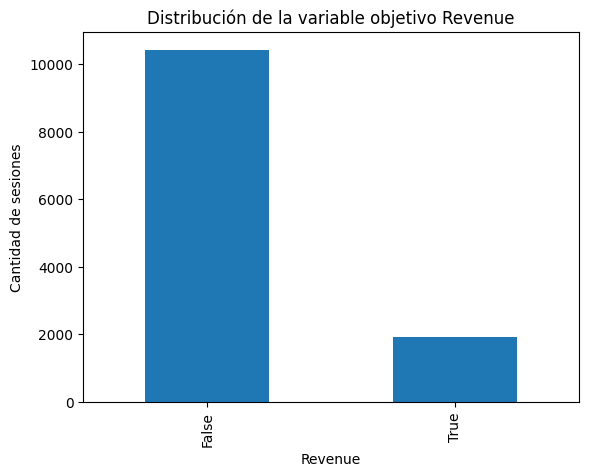

In [10]:
df["Revenue"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo Revenue")
plt.xlabel("Revenue")
plt.ylabel("Cantidad de sesiones")
plt.show()

In [11]:
#Hisograma de pagueValues

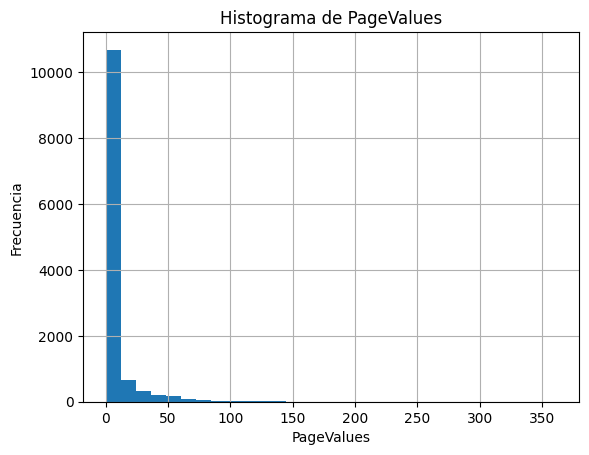

In [12]:
df["PageValues"].hist(bins=30)
plt.title("Histograma de PageValues")
plt.xlabel("PageValues")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
#Histograma de ProductRelated

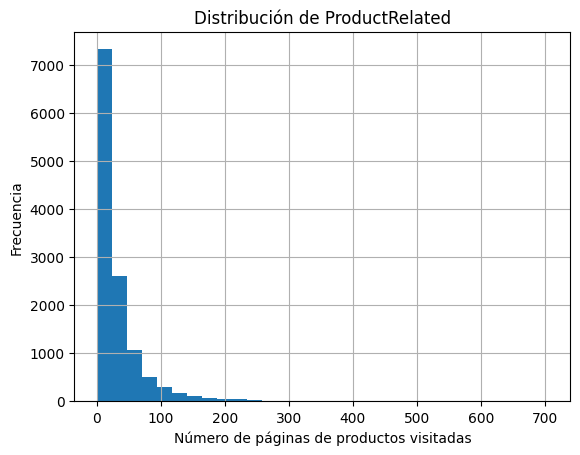

In [14]:
df["ProductRelated"].hist(bins=30)
plt.title("Distribución de ProductRelated")
plt.xlabel("Número de páginas de productos visitadas")
plt.ylabel("Frecuencia")
plt.show()

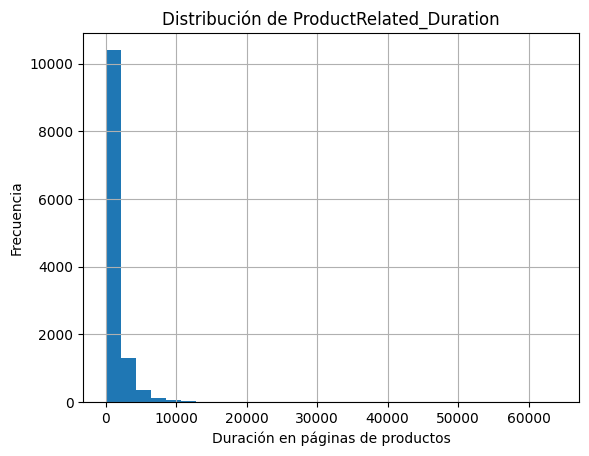

In [15]:
#Histograma de ProductRelated_Duration
df["ProductRelated_Duration"].hist(bins=30)
plt.title("Distribución de ProductRelated_Duration")
plt.xlabel("Duración en páginas de productos")
plt.ylabel("Frecuencia")
plt.show()

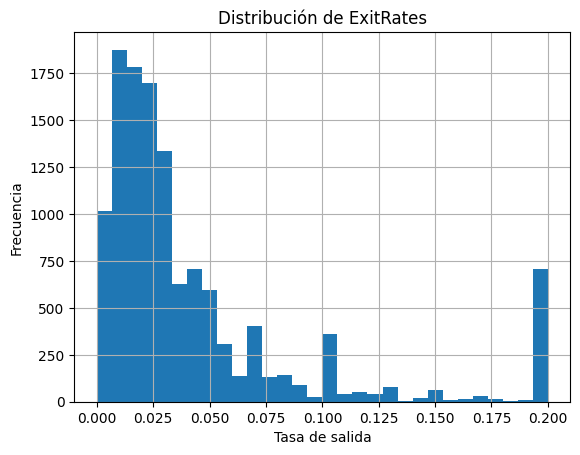

In [16]:
#Histograma de ExitRates
df["ExitRates"].hist(bins=30)
plt.title("Distribución de ExitRates")
plt.xlabel("Tasa de salida")
plt.ylabel("Frecuencia")
plt.show()

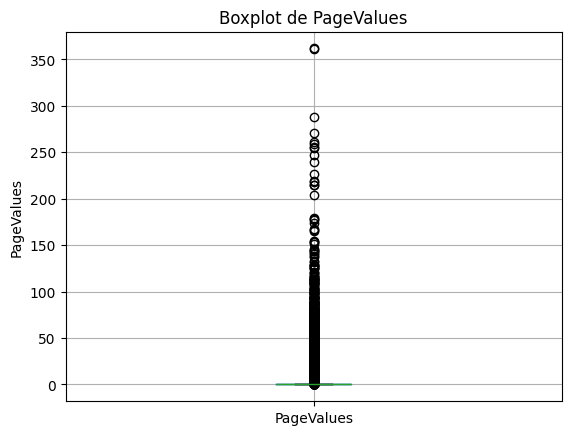

In [17]:
#Boxplot de PageValues
df.boxplot(column="PageValues")
plt.title("Boxplot de PageValues")
plt.ylabel("PageValues")
plt.show()

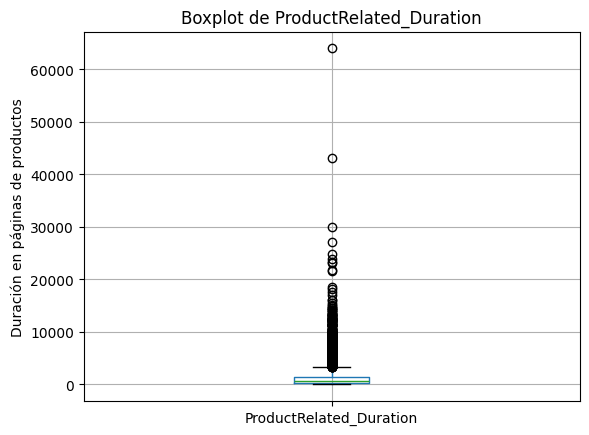

In [18]:
#Boxplot de ProductRelated_Duration
df.boxplot(column="ProductRelated_Duration")
plt.title("Boxplot de ProductRelated_Duration")
plt.ylabel("Duración en páginas de productos")
plt.show()

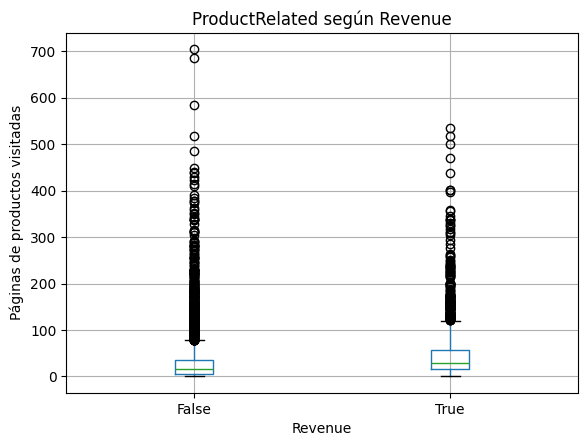

In [19]:
#Boxplot de ProductRelated según Revenue
df.boxplot(column="ProductRelated", by="Revenue")
plt.title("ProductRelated según Revenue")
plt.suptitle("")
plt.xlabel("Revenue")
plt.ylabel("Páginas de productos visitadas")
plt.show()

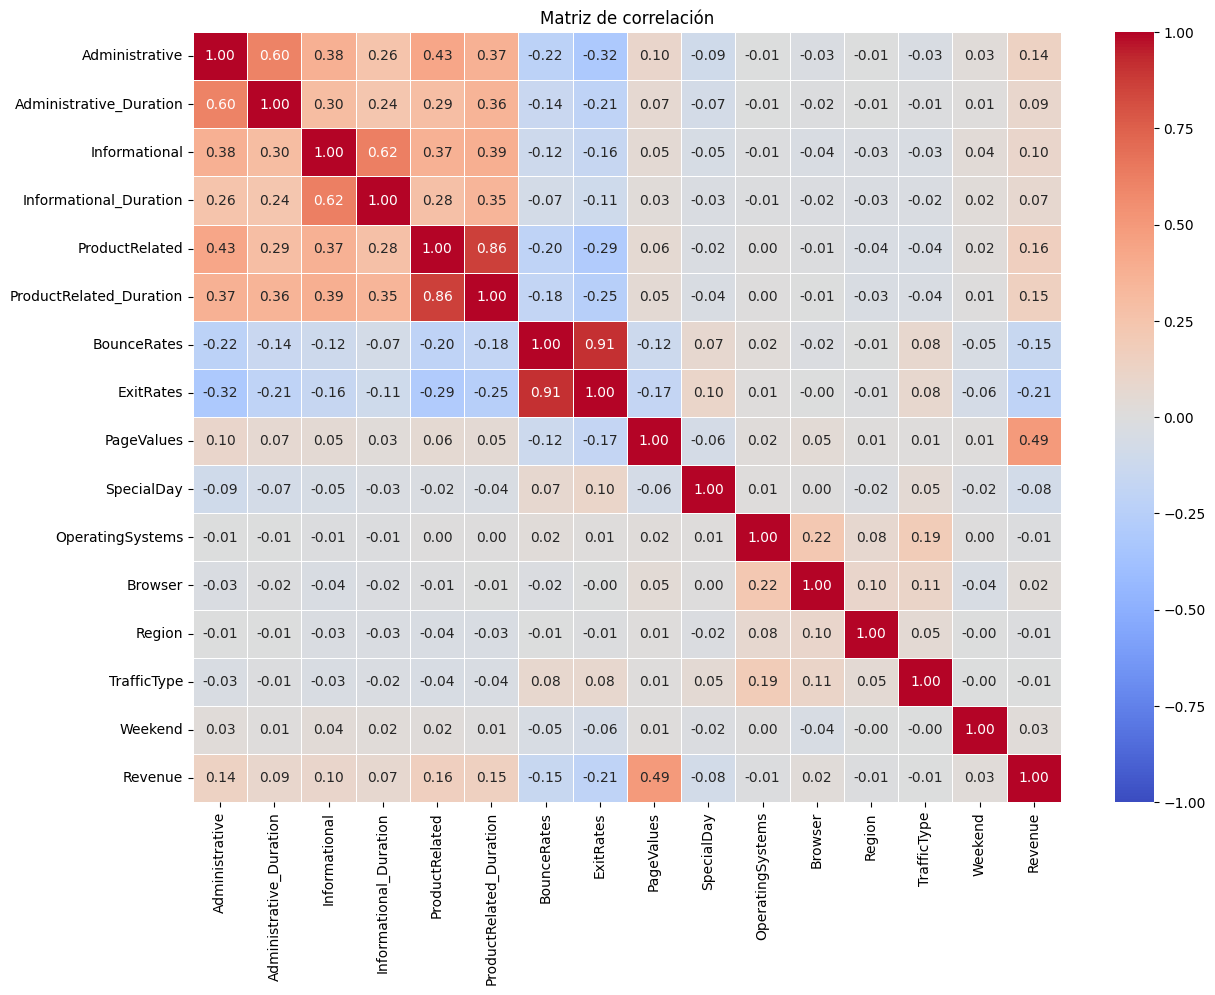

In [20]:
columnas_correlacion = df.select_dtypes(include=["int64", "float64", "bool"]).columns
df_correlacion = df[columnas_correlacion].copy()
df_correlacion["Revenue"] = df_correlacion["Revenue"].astype(int)

correlacion = df_correlacion.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlacion,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

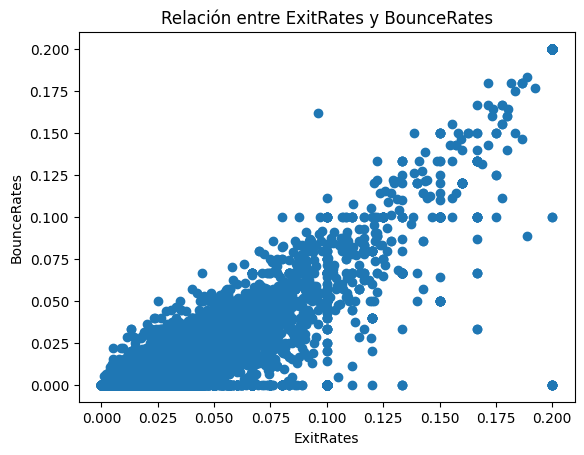

In [21]:
#Scatter plot: ExitRates vs BounceRates
plt.scatter(df["ExitRates"], df["BounceRates"])
plt.title("Relación entre ExitRates y BounceRates")
plt.xlabel("ExitRates")
plt.ylabel("BounceRates")
plt.show()

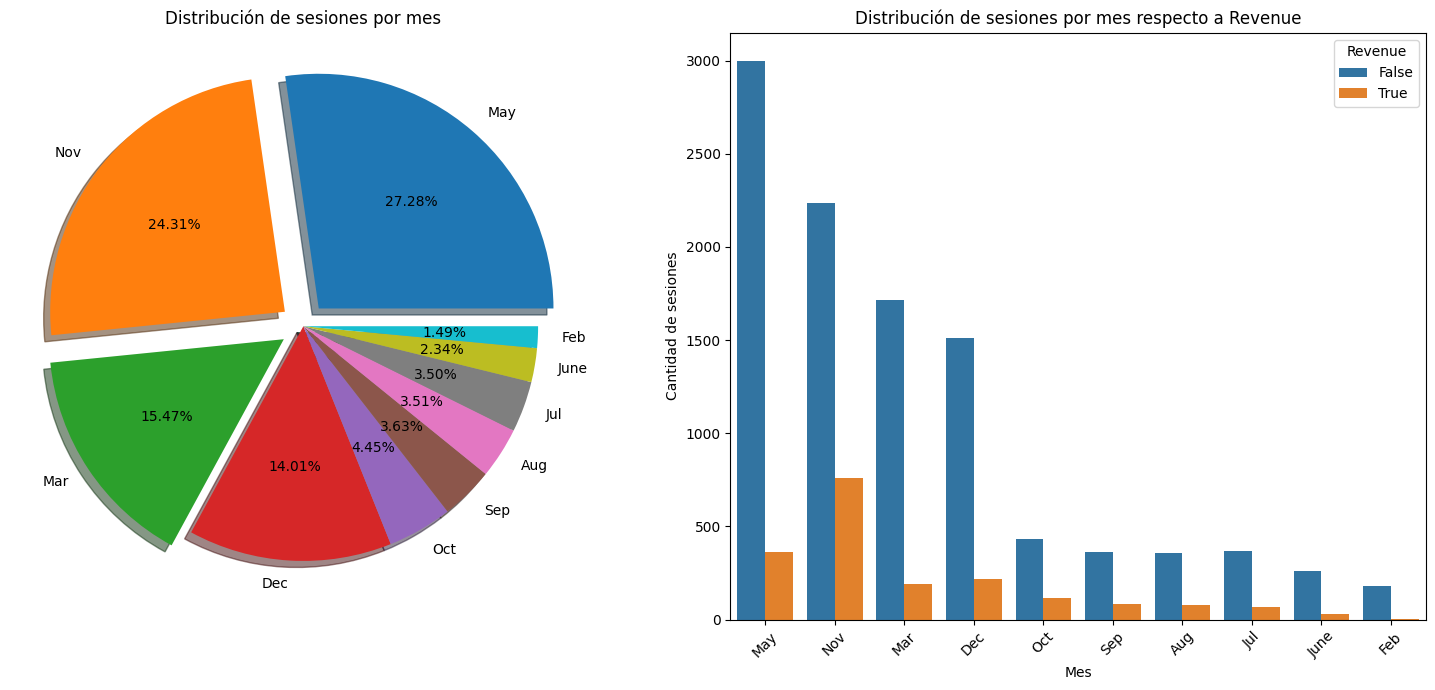

In [22]:
plt.figure(figsize=(15, 7))

# Gráfica 1: distribución de visitas por mes
plt.subplot(1, 2, 1)
plt.title("Distribución de sesiones por mes")

conteo_meses = df["Month"].value_counts()

plt.pie(
    x=conteo_meses,
    labels=conteo_meses.index,
    autopct="%.2f%%",
    shadow=True,
    explode=[0.1 if i < 3 else 0 for i in range(len(conteo_meses))]
)

# Gráfica 2: distribución de meses respecto a Revenue
plt.subplot(1, 2, 2)
plt.title("Distribución de sesiones por mes respecto a Revenue")

sns.countplot(
    x="Month",
    hue="Revenue",
    data=df,
    order=conteo_meses.index
)

plt.xlabel("Mes")
plt.ylabel("Cantidad de sesiones")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
#Tratamiento de nulos 

In [24]:
#Comprobamos los nulos 
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [25]:
df.isnull().sum().sum()

np.int64(0)

In [26]:
# Crear una copia del dataset original
df_nulos = df.copy()
# Fijar semilla para que el resultado sea reproducible
np.random.seed(42)
# Columnas donde se generarán valores faltantes
columnas_con_nulos = [
    "PageValues",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "Month",
    "VisitorType"
]
# Porcentaje de valores nulos a generar
porcentaje_nulos = 0.02
# Generar valores nulos aleatoriamente
for columna in columnas_con_nulos:
    indices = df_nulos.sample(
        frac=porcentaje_nulos,
        random_state=42
    ).index
    
    df_nulos.loc[indices, columna] = np.nan
# Mostrar valores nulos generados en las columnas seleccionadas
df_nulos[columnas_con_nulos].isnull().sum()

PageValues                 247
ProductRelated_Duration    247
BounceRates                247
ExitRates                  247
Month                      247
VisitorType                247
dtype: int64

In [27]:
df_nulos.isnull().sum()

Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration    247
BounceRates                247
ExitRates                  247
PageValues                 247
SpecialDay                   0
Month                      247
OperatingSystems             0
Browser                      0
Region                       0
TrafficType                  0
VisitorType                247
Weekend                      0
Revenue                      0
dtype: int64

In [28]:
# Crear una copia para aplicar el tratamiento de valores faltantes
df_tratado = df_nulos.copy()

# Columnas numéricas con valores nulos
columnas_numericas_nulos = [
    "PageValues",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
]

# Columnas categóricas con valores nulos
columnas_categoricas_nulos = [
    "Month",
    "VisitorType"
]

# Imputar variables numéricas con la mediana
for columna in columnas_numericas_nulos:
    mediana = df_tratado[columna].median()
    df_tratado[columna] = df_tratado[columna].fillna(mediana)

# Imputar variables categóricas con la moda
for columna in columnas_categoricas_nulos:
    moda = df_tratado[columna].mode()[0]
    df_tratado[columna] = df_tratado[columna].fillna(moda)

# Verificar que ya no existan valores nulos
df_tratado.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [29]:
df_tratado.isnull().sum().sum()

np.int64(0)

## 3.2 Conversión de variables categóricas a numéricas

En esta sección se transforman las variables categóricas a formato numérico para que puedan ser utilizadas por los modelos de clasificación. Se trabaja con una copia del dataset ya tratado de valores faltantes, conservando intacto el dataset original.

In [30]:
# Crear una copia del dataset tratado para continuar con la preparación
updated_df = df_tratado.copy()

# Variables categóricas que requieren transformación
columnas_categoricas = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

updated_df[columnas_categoricas].head()

,Month,VisitorType,Weekend,OperatingSystems,Browser,Region,TrafficType
0,Feb,Returning_Visitor,False,1,1,1,1
1,Feb,Returning_Visitor,False,2,2,1,2
2,Feb,Returning_Visitor,False,4,1,9,3
3,Feb,Returning_Visitor,False,3,2,2,4
4,Feb,Returning_Visitor,True,3,3,1,4


In [31]:
# Revisar la cantidad de categorías únicas en cada variable categórica
updated_df[columnas_categoricas].nunique()

Month               10
VisitorType          3
Weekend              2
OperatingSystems     8
Browser             13
Region               9
TrafficType         20
dtype: int64

In [32]:
# Aplicar One-Hot Encoding a las variables categóricas
updated_df_encoded = pd.get_dummies(
    updated_df,
    columns=columnas_categoricas,
    drop_first=True,
    dtype=int
)

updated_df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
# Convertir la variable objetivo Revenue de True/False a 1/0
updated_df_encoded["Revenue"] = updated_df_encoded["Revenue"].astype(int)

updated_df_encoded["Revenue"].value_counts()

Revenue
0    10422
1     1908
Name: count, dtype: int64

In [34]:
# Verificar los tipos de datos después de la conversión
updated_df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Revenue                        12330 non-null  int64  
 11  Month_Dec                      12330 non-null  int64  
 12  Month_Feb                      12330 non-null  int64  
 1

In [35]:
# Comparar dimensiones antes y después de aplicar One-Hot Encoding
print("Dimensiones antes de One-Hot Encoding:", updated_df.shape)
print("Dimensiones después de One-Hot Encoding:", updated_df_encoded.shape)

Dimensiones antes de One-Hot Encoding: (12330, 18)
Dimensiones después de One-Hot Encoding: (12330, 69)


## 3.3 Escalado o normalización

En esta sección se aplica `StandardScaler` a las variables numéricas continuas. Esta técnica es adecuada porque el modelo SVM es sensible a la escala de los datos.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables independientes y variable dependiente
X = updated_df_encoded.drop("Revenue", axis=1)
y = updated_df_encoded["Revenue"]

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (9864, 68)
Dimensiones de X_test: (2466, 68)
Dimensiones de y_train: (9864,)
Dimensiones de y_test: (2466,)


In [37]:
# Columnas numéricas continuas que serán escaladas
columnas_a_escalar = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

columnas_a_escalar

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay']

In [38]:
# Crear copias para no modificar directamente X_train y X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Aplicar StandardScaler
scaler = StandardScaler()

X_train_scaled[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_test_scaled[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

X_train_scaled.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
4263,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.092416,-0.349454,-0.611748,0.349986,3.663440,...,0,0,0,0,0,0,0,0,0,0
5905,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.536130,0.369901,1.173202,-0.316754,-0.311499,...,0,0,0,0,0,0,0,0,0,0
9434,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.597051,-0.455241,0.143321,-0.316754,-0.311499,...,0,0,0,0,0,0,0,0,0,0
3505,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.018279,-0.197384,-0.114149,0.728168,3.663440,...,0,0,0,0,0,0,0,0,0,0
2067,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.181577,-0.455241,-0.874480,2.653291,-0.311499,...,0,0,0,0,0,0,0,0,0,0


In [39]:
# Estadísticas descriptivas después del escalado
X_train_scaled[columnas_a_escalar].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,9864.0,-4.610172e-17,1.000051,-0.698294,-0.698294,-0.396996,0.506897,7.436746
Administrative_Duration,9864.0,-1.872882e-17,1.000051,-0.452341,-0.452341,-0.407798,0.065472,18.471518
Informational,9864.0,-2.161018e-18,1.000051,-0.395782,-0.395782,-0.395782,-0.395782,18.426209
Informational_Duration,9864.0,2.161018e-17,1.000051,-0.244589,-0.244589,-0.244589,-0.244589,17.782157
ProductRelated,9864.0,4.358053e-17,1.000051,-0.721175,-0.560673,-0.308456,0.150121,15.443645
ProductRelated_Duration,9864.0,2.881357e-17,1.000051,-0.619262,-0.519643,-0.302607,0.139303,33.211941
BounceRates,9864.0,4.322036e-18,1.000051,-0.455241,-0.455241,-0.391769,-0.111432,3.670470
ExitRates,9864.0,-6.122884e-17,1.000051,-0.886561,-0.592309,-0.365793,0.143321,3.232965
PageValues,9864.0,-1.656781e-17,1.000051,-0.316754,-0.316754,-0.316754,-0.316754,19.334425
SpecialDay,9864.0,-7.473521e-17,1.000051,-0.311499,-0.311499,-0.311499,-0.311499,4.657175


## 3.4 Selección de atributos

La variable dependiente es `Revenue`, ya que indica si una sesión generó ingresos o no. Las variables independientes son todos los atributos restantes después del tratamiento de nulos, codificación de variables categóricas y escalado de variables numéricas.

In [40]:
# Confirmar variables independientes X y variable dependiente y
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("Distribución de la variable dependiente Revenue:")
print(y.value_counts())

Dimensiones de X: (12330, 68)
Dimensiones de y: (12330,)
Distribución de la variable dependiente Revenue:
Revenue
0    10422
1     1908
Name: count, dtype: int64


In [41]:
# Mostrar las primeras columnas usadas como variables independientes
X.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month_Dec',
       'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor', 'Weekend_True', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6',
       'Browser_7', 'Browser_8', 'Browser_9', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_2', 'Region_3', 'Region_4',
       'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
       'TrafficType_6', 'TrafficType_7', 'TrafficType_

## 4. Modelado

En esta etapa se entrenan dos modelos de clasificación: SVM, que es el modelo obligatorio, y Random Forest, utilizado como segundo algoritmo de clasificación.

In [42]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import time

In [43]:
# Crear el modelo SVM
modelo_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

# Medir tiempo de entrenamiento
inicio_svm = time.time()
modelo_svm.fit(X_train_scaled, y_train)
fin_svm = time.time()

tiempo_svm = fin_svm - inicio_svm

print("Modelo SVM entrenado correctamente")
print("Tiempo de entrenamiento SVM:", tiempo_svm, "segundos")

Modelo SVM entrenado correctamente
Tiempo de entrenamiento SVM: 46.66613435745239 segundos


In [44]:
# Realizar predicciones con SVM
y_pred_svm = modelo_svm.predict(X_test_scaled)
y_pred_svm[:10]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [45]:
# Crear el modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Medir tiempo de entrenamiento
inicio_rf = time.time()
modelo_rf.fit(X_train_scaled, y_train)
fin_rf = time.time()

tiempo_rf = fin_rf - inicio_rf

print("Modelo Random Forest entrenado correctamente")
print("Tiempo de entrenamiento Random Forest:", tiempo_rf, "segundos")

Modelo Random Forest entrenado correctamente
Tiempo de entrenamiento Random Forest: 0.7271158695220947 segundos


In [46]:
# Realizar predicciones con Random Forest
y_pred_rf = modelo_rf.predict(X_test_scaled)
y_pred_rf[:10]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [47]:
# Comparar tiempos de entrenamiento
print("Tiempo de entrenamiento SVM:", tiempo_svm, "segundos")
print("Tiempo de entrenamiento Random Forest:", tiempo_rf, "segundos")

Tiempo de entrenamiento SVM: 46.66613435745239 segundos
Tiempo de entrenamiento Random Forest: 0.7271158695220947 segundos


## 5. Evaluación

En esta etapa se comparan los modelos entrenados mediante accuracy con k-fold cross-validation, matriz de confusión, precision, recall, F1-score, curvas ROC, AUC y tiempo de entrenamiento.

In [48]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

# Configurar k-fold estratificado
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy con k-fold para SVM
accuracy_svm_kfold = cross_val_score(
    modelo_svm,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

# Accuracy con k-fold para Random Forest
accuracy_rf_kfold = cross_val_score(
    modelo_rf,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print("Accuracy SVM por fold:", accuracy_svm_kfold)
print("Accuracy promedio SVM:", accuracy_svm_kfold.mean())

print("Accuracy Random Forest por fold:", accuracy_rf_kfold)
print("Accuracy promedio Random Forest:", accuracy_rf_kfold.mean())

Accuracy SVM por fold: [0.85808414 0.87987836 0.85554992 0.87379625 0.87221095]
Accuracy promedio SVM: 0.8679039240702835
Accuracy Random Forest por fold: [0.89761784 0.89559047 0.89052205 0.90522048 0.90517241]
Accuracy promedio Random Forest: 0.8988246500166035


In [49]:
# Accuracy en el conjunto de prueba
accuracy_svm_test = accuracy_score(y_test, y_pred_svm)
accuracy_rf_test = accuracy_score(y_test, y_pred_rf)

print("Accuracy SVM en prueba:", accuracy_svm_test)
print("Accuracy Random Forest en prueba:", accuracy_rf_test)

Accuracy SVM en prueba: 0.8592862935928629
Accuracy Random Forest en prueba: 0.897404703974047


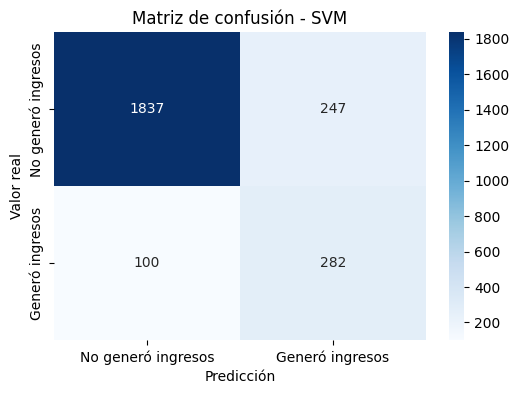

In [50]:
# Matriz de confusión para SVM
matriz_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No generó ingresos", "Generó ingresos"],
    yticklabels=["No generó ingresos", "Generó ingresos"]
)

plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

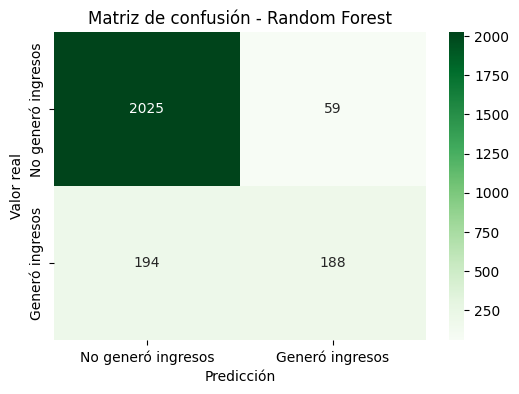

In [51]:
# Matriz de confusión para Random Forest
matriz_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No generó ingresos", "Generó ingresos"],
    yticklabels=["No generó ingresos", "Generó ingresos"]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [52]:
# Reporte de clasificación para SVM
print("Reporte de clasificación - SVM")
print(classification_report(y_test, y_pred_svm))

Reporte de clasificación - SVM
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      2084
           1       0.53      0.74      0.62       382

    accuracy                           0.86      2466
   macro avg       0.74      0.81      0.77      2466
weighted avg       0.88      0.86      0.87      2466



In [53]:
# Reporte de clasificación para Random Forest
print("Reporte de clasificación - Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.76      0.49      0.60       382

    accuracy                           0.90      2466
   macro avg       0.84      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



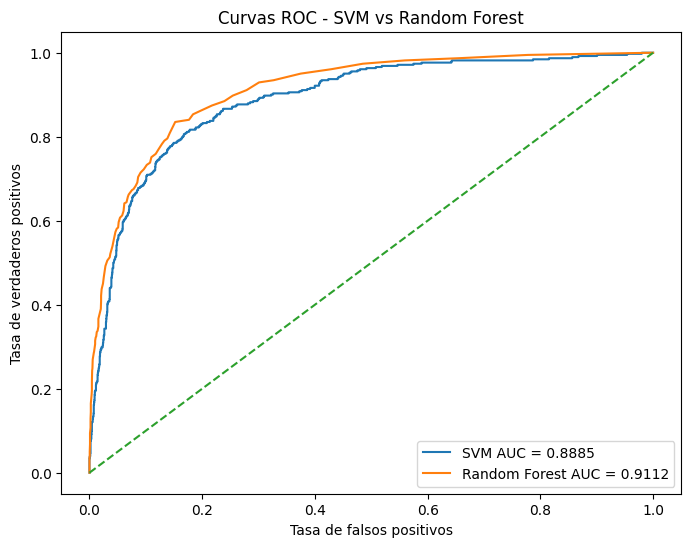

In [54]:
# Probabilidades de la clase positiva para SVM y Random Forest
y_prob_svm = modelo_svm.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

# Curva ROC para SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# Curva ROC para Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Graficar curvas ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {auc_svm:.4f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curvas ROC - SVM vs Random Forest")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

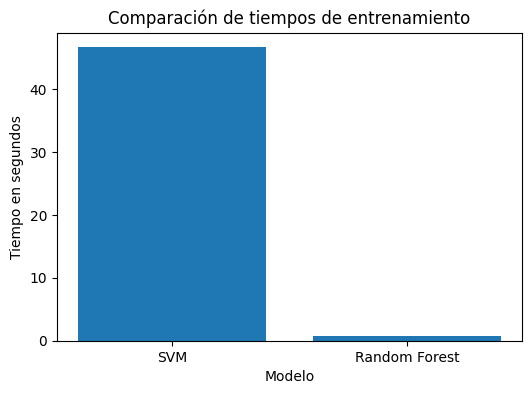

Tiempo de entrenamiento SVM: 46.66613435745239 segundos
Tiempo de entrenamiento Random Forest: 0.7271158695220947 segundos


In [55]:
# Comparación de tiempos de entrenamiento
modelos = ["SVM", "Random Forest"]
tiempos = [tiempo_svm, tiempo_rf]

plt.figure(figsize=(6, 4))
plt.bar(modelos, tiempos)
plt.title("Comparación de tiempos de entrenamiento")
plt.xlabel("Modelo")
plt.ylabel("Tiempo en segundos")
plt.show()

print("Tiempo de entrenamiento SVM:", tiempo_svm, "segundos")
print("Tiempo de entrenamiento Random Forest:", tiempo_rf, "segundos")

In [56]:
# Tabla resumen de resultados
comparacion_modelos = pd.DataFrame({
    "Modelo": ["SVM", "Random Forest"],
    "Accuracy prueba": [accuracy_svm_test, accuracy_rf_test],
    "Accuracy k-fold promedio": [accuracy_svm_kfold.mean(), accuracy_rf_kfold.mean()],
    "AUC": [auc_svm, auc_rf],
    "Tiempo entrenamiento": [tiempo_svm, tiempo_rf]
})

comparacion_modelos

,Modelo,Accuracy prueba,Accuracy k-fold promedio,AUC,Tiempo entrenamiento
0,SVM,0.859286,0.867904,0.888520,46.666134
1,Random Forest,0.897405,0.898825,0.911162,0.727116


## 6. Conclusiones del notebook

En este proyecto se aplicó la metodología CRISP-DM para resolver un problema de clasificación utilizando el dataset **Online Shoppers Purchasing Intention Dataset**. Se realizó la carga remota del dataset, exploración inicial, análisis exploratorio, tratamiento de valores faltantes, conversión de variables categóricas, escalado, selección de atributos, entrenamiento de SVM y Random Forest, así como la evaluación de ambos modelos.

La variable objetivo utilizada fue `Revenue`, ya que indica si una sesión generó ingresos o no. A partir del análisis y la evaluación, Random Forest obtuvo un mejor desempeño general que SVM, con un accuracy aproximado mayor y un menor tiempo de entrenamiento. Por esta razón, para este dataset se considera que Random Forest fue el modelo más adecuado bajo las condiciones utilizadas.

Aunque los resultados fueron aceptables, el estudio podría mejorar mediante ajuste de hiperparámetros, técnicas de balanceo de clases, comparación con otros algoritmos y uso de más información contextual sobre los usuarios o productos.